# SDG 3 Indicator Text Classification
## Emmanuella Briggs: Experiment 1-4
### Baseline Models: TF-IDF with Logistic Regression, SVM, Combined Features, and Class Balancing

## Overview
This notebook is Emmanuella's contribution to the groups multi-label text clasification pipeline for SDG 3 for indicator prediction. It picks up directly from Birassa's preprocessing and feature engineering notebook, loading the saved processed data and running four structured experiments.

All experiments use TF-IDF-based feature representations and focus on establishing strong classical baselines before the team moves to embedding-based models in Evolu's Notebook


| Experiment | Model | Features | Key Change |
|---|---|---|---|
| Exp 1 | Logistic Regression (OvR) | TF-IDF word n-grams | Baseline |
| Exp 2 | Linear SVM (OvR) | TF-IDF word n-grams | Swap classifier |
| Exp 3 | Best of Exp 1/2 | Combined TF-IDF (word + char) | Add char n-grams |
| Exp 4 | Best of Exp 1/2 | TF-IDF word + class weights | Address class imbalance |

**Evaluation metric:** Hamming Loss (lower = better)

> **Runtime:** CPU is sufficient for all 4 experiments in this notebook.

## Cell 1 Imports & Environment Setup

This cell loads every external library the notebook depends on before any data or modeling work begins.

**NumPy and Pandas** handle all numerical operations and data manipulation, NumPy for array math and Pandas for loading and structuring tabular data. **Matplotlib and Seaborn** are used to generate all visualisations across the experiments. **Warnings** is set to ignore non-critical alerts that would otherwise clutter the output. **Time** is imported to measure how long each model takes to train, which becomes part of the experiment log. **load_npz** from SciPy loads the sparse TF-IDF matrices saved by Person 1 these are stored in a compressed sparse format rather than regular arrays because TF-IDF vectors are mostly zeros, and storing them as dense arrays would use significantly more memory.

From Scikit-learn we import the four components that power all four experiments. **LogisticRegression** and **LinearSVC** are the two classifiers being compared in Experiments 1 and 2. **OneVsRestClassifier** is the multi-label wrapper, because each text can belong to multiple SDG 3 indicators simultaneously, we cannot use a standard single-label classifier directly. OneVsRest solves this by training one independent binary classifier per label, 27 classifiers in total, each answering "is this indicator relevant to this text, yes or no?". **hamming_loss** and **f1_score** are the evaluation metrics used throughout, Hamming Loss is the primary metric for this assignment and F1 score (both micro and macro) gives a fuller picture of performance across common and rare labels.

`SEED = 42` is set and passed to every model that has randomness, ensuring that results are reproducible meaning anyone who runs this notebook will get the exact same numbers. The plot settings increase figure resolution to 130 DPI and remove the top and right axis borders for cleaner visualisations.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from scipy.sparse import load_npz

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import hamming_loss, f1_score

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False
})

print('Libraries loaded')

Libraries loaded


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 2 - Loading Processed Data

Rather than repeating Person 1's entire preprocessing pipeline, we load the already-processed feature matrices directly from the shared Google Drive folder. This keeps the notebook focused on modeling and ensures every team member is working with identical data splits.

We load two versions of the features. `X_train_tfidf` and `X_val_tfidf` are word-level TF-IDF vectors with 50,000 features, used in Experiments 1 and 2. `X_train_combined` and `X_val_combined` are the word plus character n-gram TF-IDF vectors with 80,000 features, used in Experiment 3. Both are loaded as sparse matrices using `load_npz` because storing them as dense arrays would be unnecessarily large in memory given that most values are zero.

`label_support` counts how many training samples are positive for each of the 27 indicators. This is used later in Experiment 4 to visualise how class imbalance affects performance across rare and common labels.

In [4]:
SAVE_DIR = '/content/drive/MyDrive/SDG_Assignment/processed_data'

# Labels
y_train = np.load(f'{SAVE_DIR}/y_train.npy')
y_val   = np.load(f'{SAVE_DIR}/y_val.npy')

# TF-IDF word features
X_train_tfidf = load_npz(f'{SAVE_DIR}/X_train_tfidf.npz')
X_val_tfidf   = load_npz(f'{SAVE_DIR}/X_val_tfidf.npz')

# Combined TF-IDF (word + char)
X_train_combined = load_npz(f'{SAVE_DIR}/X_train_combined_tfidf.npz')
X_val_combined   = load_npz(f'{SAVE_DIR}/X_val_combined_tfidf.npz')

# Indicator names
ALL_INDICATORS = np.load(f'{SAVE_DIR}/indicator_names.npy', allow_pickle=True).tolist()
SHORT_NAMES    = [ind.split(' - ')[0] if ' - ' in ind else ind for ind in ALL_INDICATORS]

# Label support (how many positive samples per label)
label_support = y_train.sum(axis=0)

print(f' Data loaded successfully')
print(f'   Train samples          : {y_train.shape[0]}')
print(f'   Val samples            : {y_val.shape[0]}')
print(f'   Number of labels       : {y_train.shape[1]}')
print(f'   TF-IDF word features   : {X_train_tfidf.shape[1]:,}')
print(f'   Combined TF-IDF feats  : {X_train_combined.shape[1]:,}')

 Data loaded successfully
   Train samples          : 2545
   Val samples            : 450
   Number of labels       : 27
   TF-IDF word features   : 50,000
   Combined TF-IDF feats  : 80,000


## Cell 3 - Experiment Tracker

This cell sets up the logging system used to record and compare all four experiments consistently.

`log_experiment` takes the key details of each experiment as arguments and does two things: it appends a structured row to the `results` list so all experiments can be compared in a table at the end, and it prints a formatted summary block immediately after each experiment runs. This means every experiment is documented the moment it finishes rather than being reconstructed from memory later.

`show_results_table` converts the `results` list into a Pandas DataFrame and prints a full comparison table with the best performing experiment highlighted. This table is used directly in the report results section.

The metrics logged for each experiment are Hamming Loss (the primary assignment metric), F1 Micro (overall prediction accuracy across all labels weighted by frequency), F1 Macro (average F1 across all 27 labels equally, making it sensitive to rare indicator performance), and training time in seconds.

In [5]:
results = []

def log_experiment(exp_num, name, what, why, hl, f1_micro, f1_macro, train_time, insight):
  results.append({
      'Exp'          : exp_num,
      'Name'         : name,
      'Hamming Loss' :round(hl, 4),
      'F1 Micro'     :round(f1_micro, 4),
      'F1 Macro'     :round(f1_macro, 4),
      'Train Time'   :round(train_time, 4),
  })

  border = '=' * 58
  print(f'\n{border}')
  print(f'  EXPRIMENT {exp_num} - {name}')
  print(f'{border}')
  print(f'   What changed   : {what}')
  print(f'   Why            : {why}')
  print(f'   Hamming Loss   : {hl:.4f} (the lower it is the better)')
  print(f'   F1 Micro       : {f1_micro:.4f} (the higher it is the better)')
  print(f'   F1 Macro       : {f1_macro:.4f} (the higher it is the better)')
  print(f'   Train time     : {train_time:.4f} seconds')
  print(f'   Insight        : {insight}')
  print(f'{border}\n')

def show_results_table():
  df = pd.DataFrame(results)
  print('\n Experiment Comparison Table')
  print(df.to_string(index=False))
  best = df.loc[df['Hamming Loss'].idxmin()]
  print(f'\n🏆 Best so far: Exp {best["Exp"]} — {best["Name"]}  (HL = {best["Hamming Loss"]})')
  return df

print(' Experiment tracker ready')


 Experiment tracker ready


## Cell 4 - Experiment 1: TF-IDF Word N-grams + Logistic Regression (OneVsRest)

This is the baseline experiment. The goal is not to get the best result here but to establish a reference point that every future experiment is measured against.

Logistic Regression is wrapped in `OneVsRestClassifier` because this is a multi-label problem with 27 indicators. OneVsRest trains one binary classifier per label, so the model is essentially asking "is indicator X relevant to this text?" 27 separate times. `C=1.0` is the regularisation strength controlling how much the model is penalised for complexity, `solver='lbfgs'` is chosen because it handles multi-class problems efficiently, and `max_iter=1000` gives the optimiser enough steps to converge on a dataset of this size. `n_jobs=-1` uses all available CPU cores to train the 27 classifiers in parallel.

The model is trained on `X_train_tfidf` and evaluated on `X_val_tfidf`, which are the held-out samples Person 1 set aside during the train/val split. We compute three metrics: Hamming Loss as the primary assignment metric, F1 Micro for overall label prediction quality, and F1 Macro to specifically reveal how well the model handles rare indicators. A low macro F1 at this stage is expected given the class imbalance identified in Person 1's EDA.

In [6]:
start = time.time()

lr = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=SEED),
    n_jobs=-1
)
lr.fit(X_train_tfidf, y_train)
train_time_1 = time.time() - start

y_pred_lr   = lr.predict(X_val_tfidf)
hl_lr       = hamming_loss(y_val, y_pred_lr)
f1_micro_lr = f1_score(y_val, y_pred_lr, average='micro', zero_division=0)
f1_macro_lr = f1_score(y_val, y_pred_lr, average='macro', zero_division=0)

log_experiment(
    exp_num    = 1,
    name       = 'TF-IDF Word + Logistic Regression',
    what       = 'Baseline — TF-IDF word n-grams (1,2) with Logistic Regression (OneVsRest)',
    why        = 'Establishes the simplest multi-label classifier as a benchmark for all future experiments',
    hl         = hl_lr,
    f1_micro   = f1_micro_lr,
    f1_macro   = f1_macro_lr,
    train_time = train_time_1,
    insight    = 'Records first Hamming Loss benchmark. Low macro F1 expected on rare indicators due to class imbalance.'
)


  EXPRIMENT 1 - TF-IDF Word + Logistic Regression
   What changed   : Baseline — TF-IDF word n-grams (1,2) with Logistic Regression (OneVsRest)
   Why            : Establishes the simplest multi-label classifier as a benchmark for all future experiments
   Hamming Loss   : 0.0589 (the lower it is the better)
   F1 Micro       : 0.3538 (the higher it is the better)
   F1 Macro       : 0.1656 (the higher it is the better)
   Train time     : 8.8895 seconds
   Insight        : Records first Hamming Loss benchmark. Low macro F1 expected on rare indicators due to class imbalance.



## Cell 5 - Experiment 1 Visualisation: Per-Label F1 Score

A single overall Hamming Loss number does not tell us which specific indicators the model is struggling with. This chart breaks down the F1 score for each of the 27 SDG 3 indicators individually so we can see exactly where the model is performing well and where it is failing.

Each bar is colour coded into three bands: red for F1 below 0.4 meaning the model is performing poorly on that indicator, yellow for F1 between 0.4 and 0.7 meaning moderate performance, and green for F1 above 0.7 meaning strong performance. The dashed vertical line at 0.5 acts as a minimum acceptable threshold. The `n=` value on the right of each bar shows how many positive training samples exist for that indicator, making it easy to see whether low F1 scores are directly linked to low sample counts from the class imbalance identified in Person 1's EDA.

`average=None` in the f1_score call tells Scikit-learn to return a separate score for each label rather than a single aggregated number, which is what makes this per-label breakdown possible. `zero_division=0` prevents errors on labels where the model predicts zero positives.

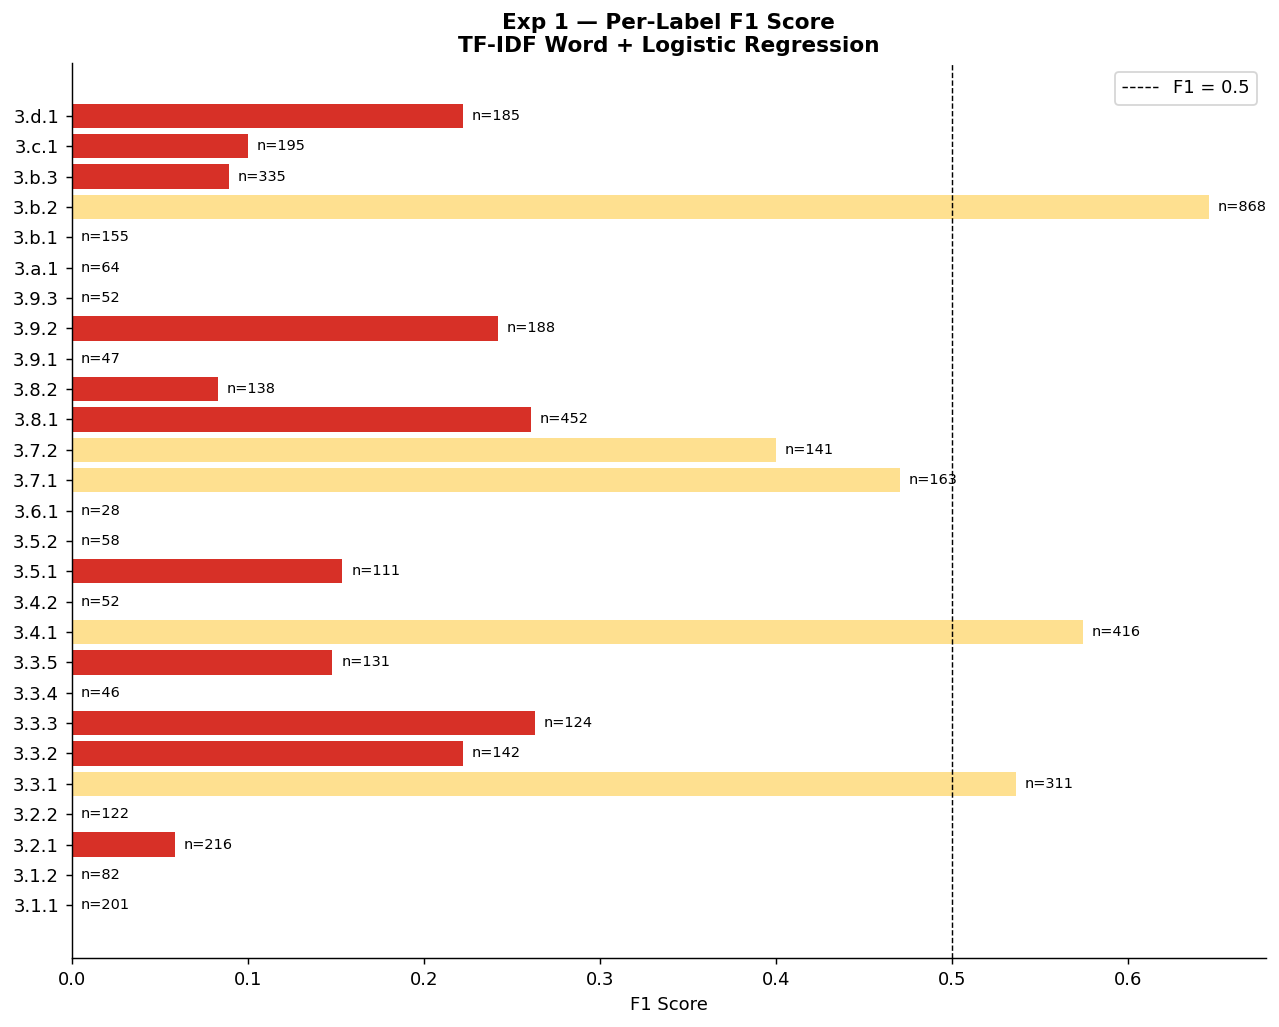

In [7]:
f1_per_label_lr = f1_score(y_val, y_pred_lr, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d73027' if f < 0.4 else '#fee090' if f < 0.7 else '#4dac26'
          for f in f1_per_label_lr]
bars = ax.barh(SHORT_NAMES, f1_per_label_lr, color=colors)
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, label='F1 = 0.5')
ax.set_xlabel('F1 Score')
ax.set_title('Exp 1 — Per-Label F1 Score\nTF-IDF Word + Logistic Regression', fontweight='bold')
ax.legend()
for bar, support in zip(bars, label_support.astype(int)):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'n={support}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('exp1_per_label_f1.png', bbox_inches='tight')
plt.show()

## Cell 6 - Experiment 2: TF-IDF Word N-grams + Linear SVM (OneVsRest)

This experiment keeps everything identical to Experiment 1 except for the classifier. Swapping only one thing at a time is intentional -- it means any difference in results can be attributed directly to the classifier choice and nothing else.

Linear SVM finds a decision boundary that maximises the margin between positive and negative samples for each label. Unlike Logistic Regression which estimates probabilities, SVM focuses purely on finding the best separating boundary, which tends to work better on sparse high-dimensional data like TF-IDF vectors where most feature values are zero. `max_iter=2000` is set higher than the Logistic Regression default because SVM optimisation on large sparse matrices can take more iterations to converge.

The result of this experiment determines which classifier gets carried into Experiments 3 and 4. If SVM produces a lower Hamming Loss than Logistic Regression, it becomes the base classifier for the remaining experiments. This is why the comparison between Experiment 1 and Experiment 2 is the most important decision point in this notebook.
``

In [8]:
start = time.time()

svm = OneVsRestClassifier(
    LinearSVC(max_iter=2000, C=1.0, random_state=SEED),
    n_jobs=-1
)
svm.fit(X_train_tfidf, y_train)
train_time_2 = time.time() - start

y_pred_svm = svm.predict(X_val_tfidf)
hl_svm = hamming_loss(y_val, y_pred_svm)
f1_micro_svm = f1_score(y_val, y_pred_svm, average='micro', zero_division=0)
f1_macro_svm = f1_score(y_val, y_pred_svm, average='macro', zero_division=0)

log_experiment(
    exp_num     = 2,
    name        = 'TF-IDF Word + Linear SVM',
    what        = 'Replaced Logistic Regression with Linear SVM, same TF-IDF word features',
    why         = 'Exp 1 gave a probalistic baseline. SVM tests whether a margin-based approach handles sparse high-dimensional TF-IDF better',
    hl          = hl_svm,
    f1_micro    = f1_micro_svm,
    f1_macro    = f1_macro_svm,
    train_time  = train_time_2,
    insight     = 'Determine the stronger classical classifier to carry into Experiments 3 and 4'
)


  EXPRIMENT 2 - TF-IDF Word + Linear SVM
   What changed   : Replaced Logistic Regression with Linear SVM, same TF-IDF word features
   Why            : Exp 1 gave a probalistic baseline. SVM tests whether a margin-based approach handles sparse high-dimensional TF-IDF better
   Hamming Loss   : 0.0464 (the lower it is the better)
   F1 Micro       : 0.5847 (the higher it is the better)
   F1 Macro       : 0.4465 (the higher it is the better)
   Train time     : 2.0487 seconds
   Insight        : Determine the stronger classical classifier to carry into Experiments 3 and 4



## Cell 7 - Experiment 1 vs 2 Visualisation: Side by Side Per-Label F1 Comparison

This chart places Experiment 1 and Experiment 2 side by side for every indicator so we can see not just which model won overall but which specific labels improved and by how much when switching from Logistic Regression to SVM.

Each indicator gets two bars, blue for LR and coral for SVM, plotted next to each other. The dashed line at 0.5 acts as the same minimum threshold used in Cell 5. This grouped bar format is more useful than comparing overall scores alone because it reveals whether SVM improved uniformly across all labels or only on specific ones.

The final three lines make the handoff decision programmatically rather than manually. Instead of us reading the numbers and deciding which classifier to use in Experiments 3 and 4, the code compares the two Hamming Loss scores directly and stores the winner in `best_clf_name`, the winning score in `best_hl`, and the winning per-label F1 array in `best_f1_label`. These three variables are then referenced automatically in Experiments 3 and 4, meaning if you re-run this notebook with different data the correct classifier is always selected without changing any code downstream.

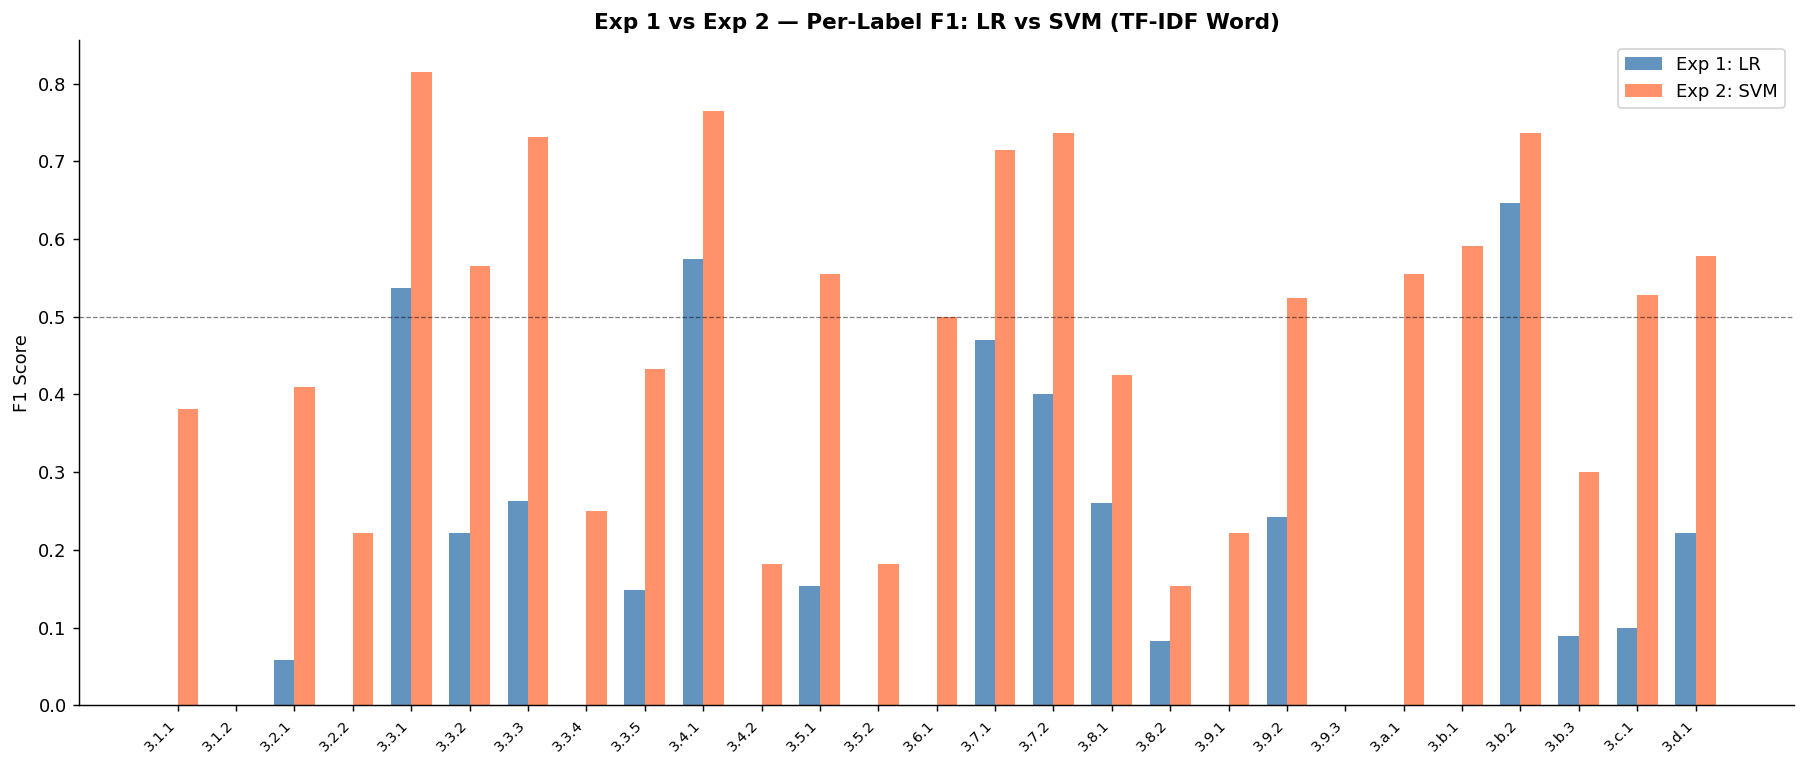

-> Best classifier to carry into Exp 3 & 4: SVM
  LR Hamming Loss : 0.0589
  SVM Hamming Loss: 0.0464


In [9]:
f1_per_label_svm = f1_score(y_val, y_pred_svm, average=None, zero_division=0)
x = np.arange(len(ALL_INDICATORS))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, f1_per_label_lr,  width, label='Exp 1: LR',  color='steelblue', alpha=0.85)
ax.bar(x + width/2, f1_per_label_svm, width, label='Exp 2: SVM', color='coral',     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(SHORT_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('F1 Score')
ax.set_title('Exp 1 vs Exp 2 — Per-Label F1: LR vs SVM (TF-IDF Word)', fontweight='bold')
ax.legend()
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
plt.tight_layout()
plt.savefig('exp1_vs_exp2_f1.png', bbox_inches='tight')
plt.show()

#Identify best classifier to carry forward
best_clf_name = 'LR' if hl_lr <= hl_svm else 'SVM'
best_hl       = min(hl_lr, hl_svm)
best_f1_label = f1_per_label_lr if hl_lr <= hl_svm else f1_per_label_svm
print(f'-> Best classifier to carry into Exp 3 & 4: {best_clf_name}')
print(f'  LR Hamming Loss : {hl_lr:.4f}')
print(f'  SVM Hamming Loss: {hl_svm:.4f}')


## Cell 8 - Experiment 3: Combined TF-IDF (Word + Char N-grams) + Best Classifier

This experiment tests whether adding character-level features on top of word features improves performance. The classifier is not chosen manually here -- it is automatically set to whichever of LR or SVM won in Experiments 1 and 2. This means the only variable changing between Experiment 2 and Experiment 3 is the feature representation, keeping the comparison clean.

The key difference is the switch from `X_train_tfidf` to `X_train_combined`. Where word TF-IDF treats each word as a single unit, character n-grams break every word into overlapping sequences of 3 to 5 characters. For this dataset specifically, that matters because SDG 3 health texts contain long domain-specific words like "antiretroviral", "tuberculosis", "neonatal" and "reproductive" that share meaningful root patterns. Character n-grams can match partial forms of these words across different documents even when the exact word form differs, giving the model a richer signal than word tokens alone. The combined feature matrix has 80,000 features compared to 50,000 for word-only TF-IDF.

`delta` measures the change in Hamming Loss compared to the best result from Experiments 1 and 2. A positive delta means Experiment 3 improved on the baseline, a negative delta means the added character features made things worse. This value is printed in the experiment log and feeds directly into the insight for the report discussion.

In [10]:
# Use the winning classifier from Exp 1 vs Exp 2
if hl_lr <= hl_svm:
    base_clf  = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=SEED)
    clf3_name = 'Logistic Regression'
else:
    base_clf  = LinearSVC(max_iter=2000, C=1.0, random_state=SEED)
    clf3_name = 'Linear SVM'

print(f'Using {clf3_name} (winner from Exp 1/2) with combined TF-IDF features')

start = time.time()
clf3 = OneVsRestClassifier(base_clf, n_jobs=-1)
clf3.fit(X_train_combined, y_train)
train_time_3 = time.time() - start

y_pred_combined   = clf3.predict(X_val_combined)
hl_combined       = hamming_loss(y_val, y_pred_combined)
f1_micro_combined = f1_score(y_val, y_pred_combined, average='micro', zero_division=0)
f1_macro_combined = f1_score(y_val, y_pred_combined, average='macro', zero_division=0)

delta = best_hl - hl_combined  # positive = improvement

log_experiment(
    exp_num    = 3,
    name       = f'Combined TF-IDF (Word + Char) + {clf3_name}',
    what       = f'Added char n-gram TF-IDF (3–5 chars) to word TF-IDF features. Classifier: {clf3_name}',
    why        = 'Exps 1 & 2 used only word-level features. Char n-grams may capture domain morphology in SDG health terms that word unigrams miss',
    hl         = hl_combined,
    f1_micro   = f1_micro_combined,
    f1_macro   = f1_macro_combined,
    train_time = train_time_3,
    insight    = f'Hamming Loss changed by {delta:+.4f} vs best baseline. Positive = char features helped.'
)

Using Linear SVM (winner from Exp 1/2) with combined TF-IDF features

  EXPRIMENT 3 - Combined TF-IDF (Word + Char) + Linear SVM
   What changed   : Added char n-gram TF-IDF (3–5 chars) to word TF-IDF features. Classifier: Linear SVM
   Why            : Exps 1 & 2 used only word-level features. Char n-grams may capture domain morphology in SDG health terms that word unigrams miss
   Hamming Loss   : 0.0449 (the lower it is the better)
   F1 Micro       : 0.6171 (the higher it is the better)
   F1 Macro       : 0.5072 (the higher it is the better)
   Train time     : 17.4586 seconds
   Insight        : Hamming Loss changed by +0.0015 vs best baseline. Positive = char features helped.



## Cell 9 - Experiment 3 Visualisation: Per-Label F1 Change from Adding Char N-grams

Rather than showing raw F1 scores again, this chart shows the difference in F1 score per label between Experiment 3 and the best baseline from Experiments 1 and 2. This makes it immediately clear which specific indicators benefited from the character n-gram features and which ones were hurt by them.

`diff` is computed by subtracting `best_f1_label` from `f1_per_label_combined` for each of the 27 indicators. A positive value means the combined features improved that indicator's F1, shown in green. A negative value means performance dropped for that indicator, shown in red. The horizontal line at zero is the reference point -- bars above it are improvements and bars below it are regressions.

This view is more informative than comparing overall scores because it is possible for the combined features to improve Hamming Loss overall while actually hurting performance on specific labels. Identifying which labels regressed is important for the report discussion because it tells us whether character n-grams are universally helpful or only beneficial for certain types of health terminology.

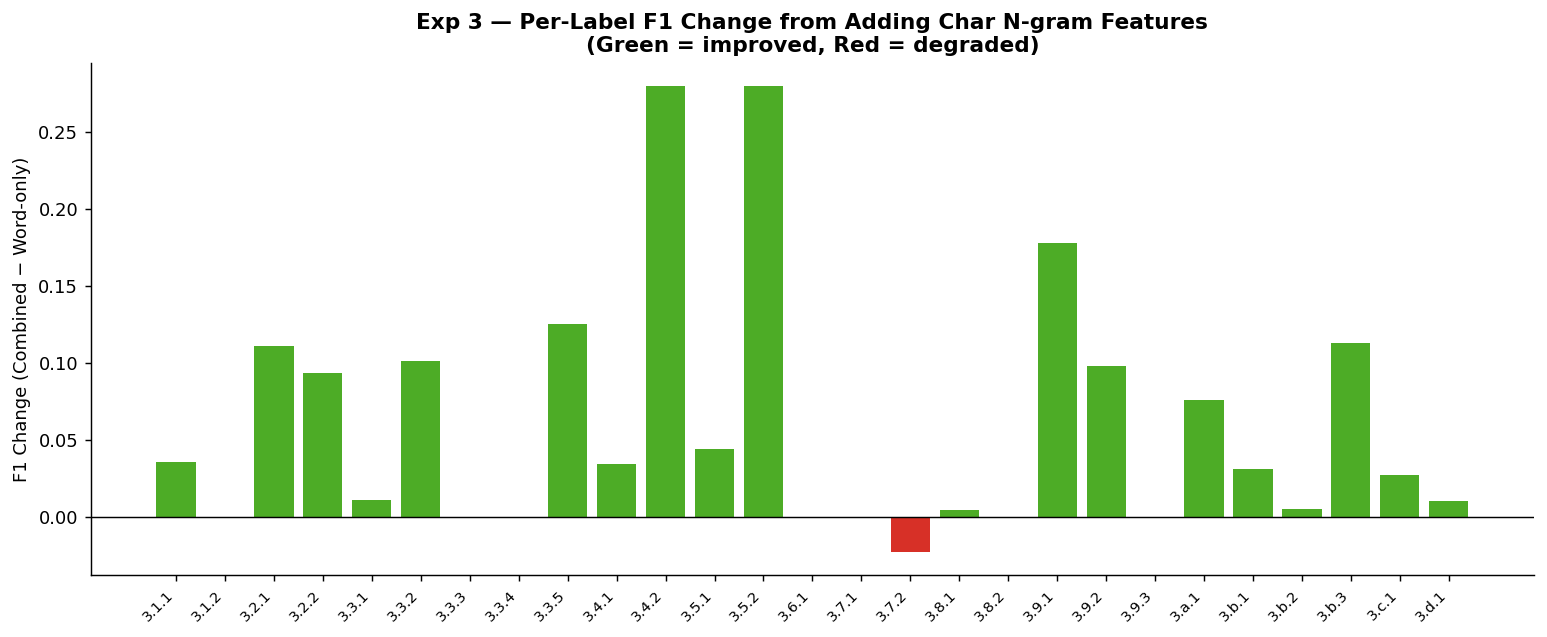

In [11]:
f1_per_label_combined = f1_score(y_val, y_pred_combined, average=None, zero_division=0)
diff   = f1_per_label_combined - best_f1_label
colors = ['#4dac26' if d > 0 else '#d73027' for d in diff]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(SHORT_NAMES, diff, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticklabels(SHORT_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_xticks(range(len(SHORT_NAMES)))
ax.set_ylabel('F1 Change (Combined − Word-only)')
ax.set_title('Exp 3 — Per-Label F1 Change from Adding Char N-gram Features\n(Green = improved, Red = degraded)', fontweight='bold')
plt.tight_layout()
plt.savefig('exp3_char_ngram_impact.png', bbox_inches='tight')
plt.show()

## Cell 10 - Experiment 4: TF-IDF Word N-grams + Balanced Class Weights

This experiment goes back to word-only TF-IDF features and focuses on addressing the class imbalance problem directly. Person 1's EDA identified imbalance ratios of up to 95:1 across some indicators, meaning for every one positive sample for a rare indicator there are 95 negative samples. Without any correction, a classifier can achieve a decent Hamming Loss simply by predicting negative for every rare label and still be right 95% of the time for that label -- which is exactly the behaviour we saw in Experiment 1.

Setting `class_weight='balanced'` tells the classifier to automatically calculate a weight for each label's positive class that is inversely proportional to how often it appears in the training data. Rare indicators get a higher weight, meaning the model is penalised much more heavily for missing a positive prediction on them. The classifier is again selected automatically from the Experiment 1 vs 2 comparison so the only variable changing here compared to Experiment 2 is the addition of balanced weights.

We deliberately go back to word-only TF-IDF rather than combined features here so that we are measuring the isolated effect of class balancing. Combining it with char n-grams at the same time would make it impossible to tell which change drove any improvement. The expected outcome is that macro F1 improves as rare label performance increases, but Hamming Loss may rise slightly because the model will now predict more positives overall, including some false positives on common labels.

In [12]:
if hl_lr <= hl_svm:
    clf4 = OneVsRestClassifier(
        LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                           class_weight='balanced', random_state=SEED),
        n_jobs=-1
    )
    clf4_name = 'Logistic Regression + class_weight=balanced'
else:
    clf4 = OneVsRestClassifier(
        LinearSVC(max_iter=2000, C=1.0,
                  class_weight='balanced', random_state=SEED),
        n_jobs=-1
    )
    clf4_name = 'Linear SVM + class_weight=balanced'

start = time.time()
clf4.fit(X_train_tfidf, y_train)
train_time_4 = time.time() - start

y_pred_balanced   = clf4.predict(X_val_tfidf)
hl_balanced       = hamming_loss(y_val, y_pred_balanced)
f1_micro_balanced = f1_score(y_val, y_pred_balanced, average='micro', zero_division=0)
f1_macro_balanced = f1_score(y_val, y_pred_balanced, average='macro', zero_division=0)

log_experiment(
    exp_num    = 4,
    name       = clf4_name,
    what       = f'Enabled class_weight=balanced on {clf3_name}, TF-IDF word features',
    why        = 'Person 1 EDA showed up to 95:1 imbalance. Baseline experiments likely underpredict rare indicators. Balanced weights re-weight the loss proportional to inverse class frequency',
    hl         = hl_balanced,
    f1_micro   = f1_micro_balanced,
    f1_macro   = f1_macro_balanced,
    train_time = train_time_4,
    insight    = 'Macro F1 change reveals whether rare labels improved. Hamming Loss may rise slightly as model predicts more positives overall — this is an acceptable tradeoff if rare label recall improves.'
)


  EXPRIMENT 4 - Linear SVM + class_weight=balanced
   What changed   : Enabled class_weight=balanced on Linear SVM, TF-IDF word features
   Why            : Person 1 EDA showed up to 95:1 imbalance. Baseline experiments likely underpredict rare indicators. Balanced weights re-weight the loss proportional to inverse class frequency
   Hamming Loss   : 0.0483 (the lower it is the better)
   F1 Micro       : 0.6334 (the higher it is the better)
   F1 Macro       : 0.5306 (the higher it is the better)
   Train time     : 8.7345 seconds
   Insight        : Macro F1 change reveals whether rare labels improved. Hamming Loss may rise slightly as model predicts more positives overall — this is an acceptable tradeoff if rare label recall improves.



## Cell 11 - Experiment 4 Visualisation: Baseline vs Balanced Weights on Rare and Common Labels

This chart is specifically designed to verify whether the balanced class weights actually helped the indicators that needed it most. Rather than showing all 27 labels, it splits the comparison into two focused panels -- the 8 rarest labels by training sample count on the left, and the 8 most common labels on the right.

`np.argsort(label_support)` sorts all 27 indicators by how many positive training samples they have, from fewest to most. The first 8 indices are the rarest labels and the last 8 are the most common. This split matters because balanced weighting should improve the rare labels specifically while potentially hurting the common ones -- showing both panels together makes that tradeoff visible in one chart.

Each panel compares two bars per indicator: the best baseline result from Experiments 1 and 2 in blue, and the balanced weights result from Experiment 4 in orange. If the orange bars are taller on the left panel, balanced weighting helped rare indicators as intended. If the blue bars are taller on the right panel, it confirms that the common labels paid a small performance cost for that improvement. This visual directly supports the discussion in the report about whether addressing class imbalance through weighting is a worthwhile tradeoff given that the assignment evaluates on Hamming Loss rather than macro F1.

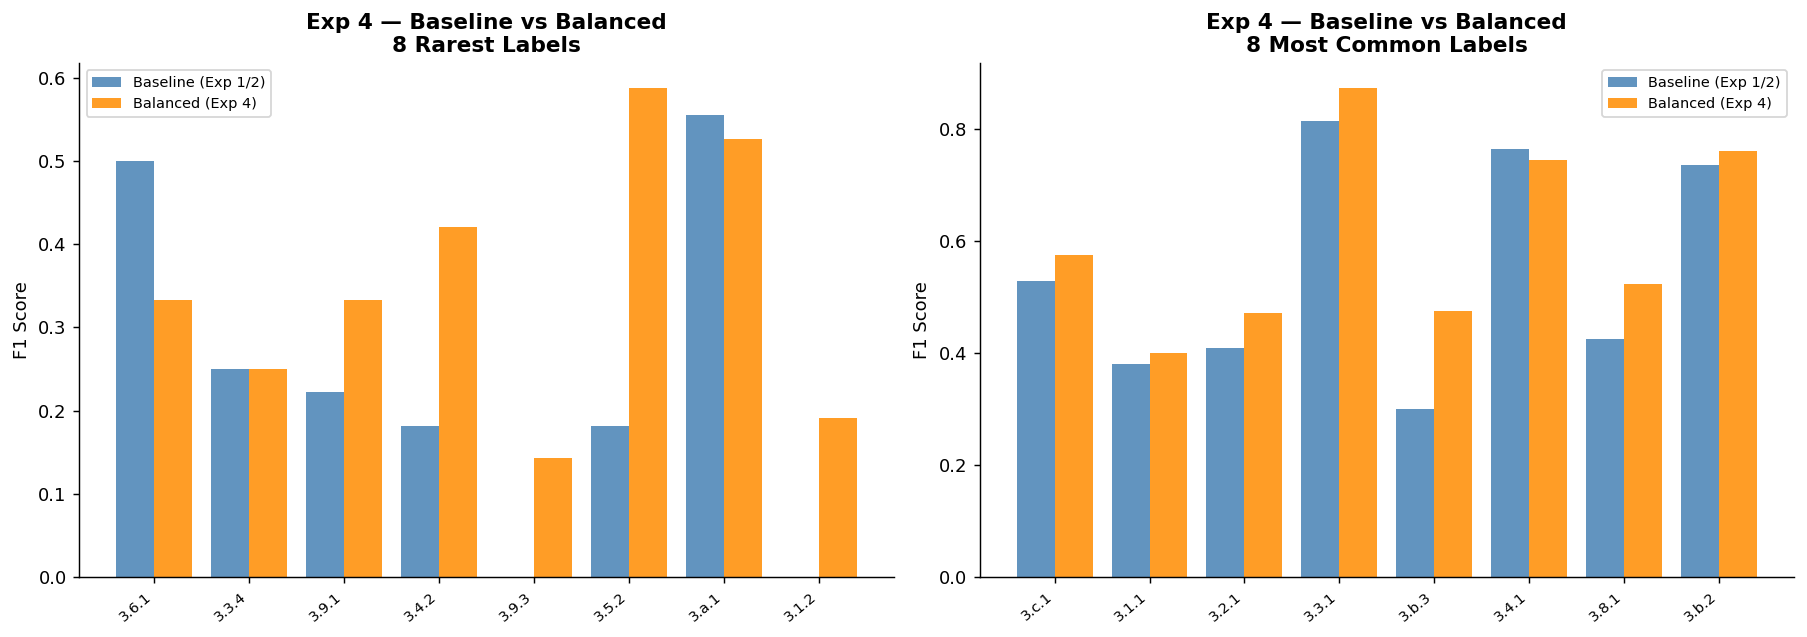

In [13]:
f1_per_label_balanced = f1_score(y_val, y_pred_balanced, average=None, zero_division=0)
label_support_sorted  = np.argsort(label_support)
rare_idx   = label_support_sorted[:8]
common_idx = label_support_sorted[-8:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, idx, title in zip(axes,
                           [rare_idx, common_idx],
                           ['8 Rarest Labels', '8 Most Common Labels']):
    names   = [SHORT_NAMES[i] for i in idx]
    f1_base = best_f1_label[idx]
    f1_bal  = f1_per_label_balanced[idx]
    x = np.arange(len(idx))
    ax.bar(x - 0.2, f1_base, 0.4, label='Baseline (Exp 1/2)', color='steelblue', alpha=0.85)
    ax.bar(x + 0.2, f1_bal,  0.4, label='Balanced (Exp 4)',   color='darkorange', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('F1 Score')
    ax.set_title(f'Exp 4 — Baseline vs Balanced\n{title}', fontweight='bold')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('exp4_class_balance_impact.png', bbox_inches='tight')
plt.show()

## Cell 12 - Results Summary: All 4 Experiments

This cell produces the final comparison across all four experiments in two formats -- a printed table and a set of bar charts -- and saves both to files for use in the report.

`show_results_table()` converts the results list that was built up across all four experiment cells into a Pandas DataFrame and prints it as a structured table. This is the table that goes directly into the report results section.

The bar chart shows three separate panels, one for each metric: Hamming Loss, F1 Micro and F1 Macro. Showing all three together is important because no single metric tells the full story. Hamming Loss is the assignment's primary metric so it determines the winning experiment, but F1 Micro shows overall prediction quality and F1 Macro reveals how well each experiment handled the rare indicators. An experiment that wins on Hamming Loss but has a very low macro F1 is still leaving rare indicators largely unpredicted, which is worth flagging in the discussion.

Each bar is labelled with its exact value for easy reading. The results CSV is saved so the table can be imported directly into the report without manually copying numbers, reducing the risk of transcription errors.


 Experiment Comparison Table
 Exp                                       Name  Hamming Loss  F1 Micro  F1 Macro  Train Time
   1          TF-IDF Word + Logistic Regression        0.0589    0.3538    0.1656      8.8895
   2                   TF-IDF Word + Linear SVM        0.0464    0.5847    0.4465      2.0487
   3 Combined TF-IDF (Word + Char) + Linear SVM        0.0449    0.6171    0.5072     17.4586
   4         Linear SVM + class_weight=balanced        0.0483    0.6334    0.5306      8.7345

🏆 Best so far: Exp 3 — Combined TF-IDF (Word + Char) + Linear SVM  (HL = 0.0449)


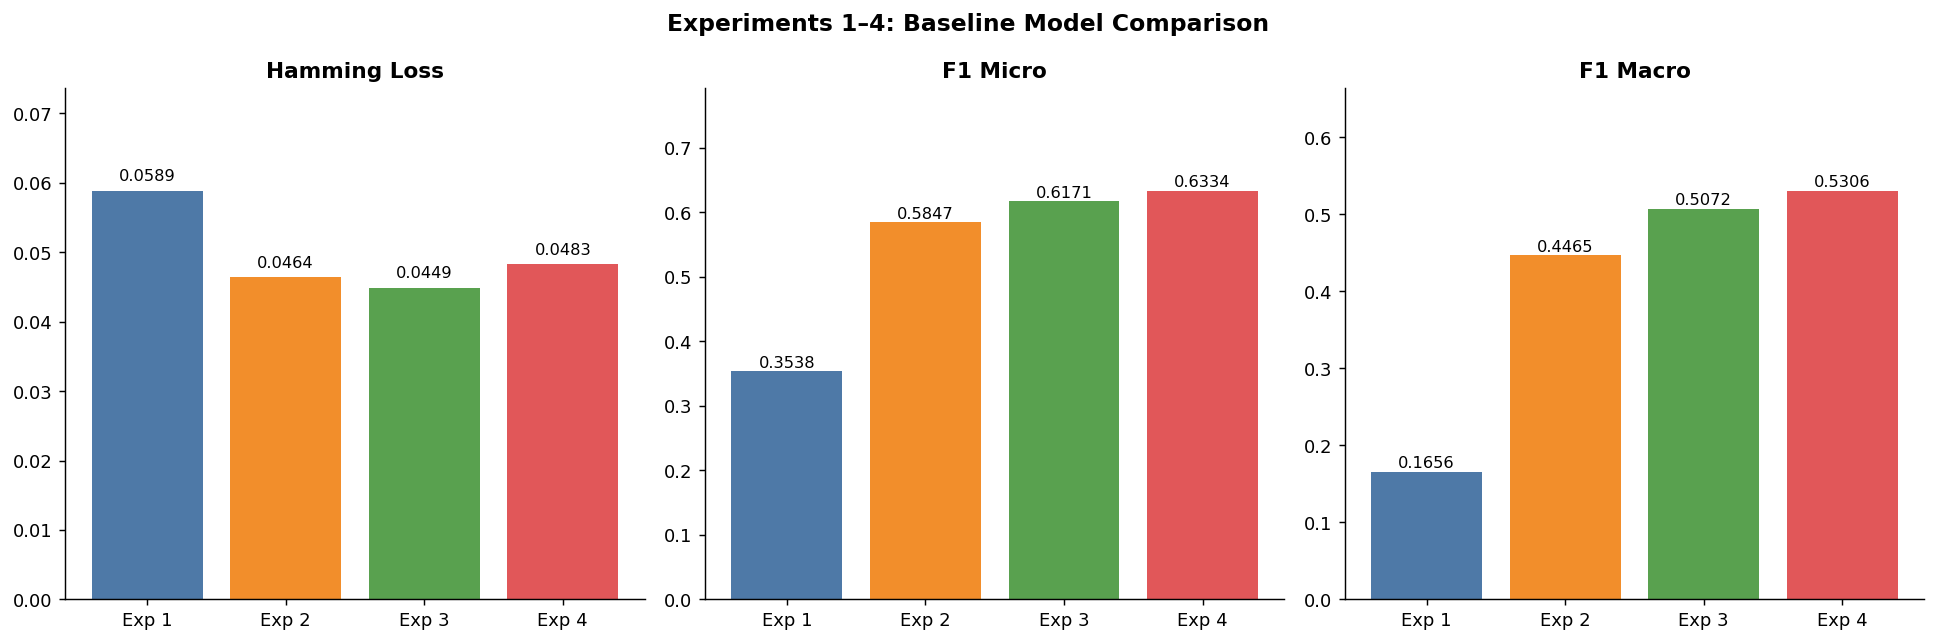

 Saved: experiments_1_4_results.csv
 Saved: experiments_1_4_summary.png


In [14]:
df_results = show_results_table()

# Summary bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Hamming Loss', 'F1 Micro', 'F1 Macro']
colors  = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
exp_labels = [f"Exp {r['Exp']}" for _, r in df_results.iterrows()]

for ax, metric in zip(axes, metrics):
    vals = df_results[metric].values
    bars = ax.bar(exp_labels, vals, color=colors)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.25)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Experiments 1–4: Baseline Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('experiments_1_4_summary.png', bbox_inches='tight')
plt.show()

# Save results CSV for the report
df_results.to_csv('experiments_1_4_results.csv', index=False)
print(' Saved: experiments_1_4_results.csv')
print(' Saved: experiments_1_4_summary.png')

## Cell 13 - Saving Best Model to Google Drive

This cell saves the best performing model from Experiments 1 to 4 so that Person 3 can load it directly without rerunning any of the experiments in this notebook.

`joblib` is used instead of Python's built-in pickle because it is specifically optimised for saving large NumPy arrays and Scikit-learn objects, which is exactly what a trained OneVsRest classifier with 27 internal SVM models is. The model is saved as `best_model_exp3.pkl` in the shared Drive models folder.

`model_info` is saved alongside the model as a lightweight reference file containing the model name, Hamming Loss, F1 Micro and F1 Macro from Experiment 3. This means Person 3 does not need to re-evaluate the model to know what benchmark they are trying to beat -- they can load the info file and see Person 2's best result immediately. This is also useful for Person 1 when compiling the final results comparison across all 10 experiments.

In [15]:
import joblib
import os

MODEL_DIR = '/content/drive/MyDrive/SDG_Assignment/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Save best model (Exp 3 -- Combined TF-IDF + Linear SVM)
joblib.dump(clf3, f'{MODEL_DIR}/best_model_exp3.pkl')

# Save the classifier name and best Hamming Loss for reference
model_info = {
    'best_exp'        : 3,
    'best_model_name' : f'Combined TF-IDF (Word + Char) + {clf3_name}',
    'best_hamming_loss': round(hl_combined, 4),
    'best_f1_micro'   : round(f1_micro_combined, 4),
    'best_f1_macro'   : round(f1_macro_combined, 4),
}
np.save(f'{MODEL_DIR}/person2_model_info.npy', model_info)

print('Models saved:')
for f in os.listdir(MODEL_DIR):
    size = os.path.getsize(f'{MODEL_DIR}/{f}') / 1024
    print(f'  {f:<45} {size:>8.1f} KB')

Models saved:
  best_model_exp3.pkl                            16887.3 KB
  person2_model_info.npy                             0.4 KB


## Cell 14 - Saving Results and Figures to Google Drive

This cell saves everything generated across Experiments 1 to 4 to a dedicated folder in the shared Drive so the whole team can access the results without rerunning the notebook.

The results CSV contains the full experiment comparison table with Hamming Loss, F1 Micro, F1 Macro and training time for all four experiments. This file is what Person 1 will use when compiling the final results section across all 10 experiments in the report, so it is important it is saved before handing off.

The five figures cover every visualisation produced in this notebook -- the per-label F1 breakdown for Experiment 1, the side by side LR vs SVM comparison, the char n-gram impact chart, the class balancing comparison on rare and common labels, and the final three-metric summary chart. The `if os.path.exists` check before each copy prevents the cell from throwing an error if a figure is missing because a previous experiment cell did not finish running, and instead prints a warning so you know exactly which cell needs to be rerun.

In [16]:
RESULTS_DIR = '/content/drive/MyDrive/SDG_Assignment/results/person2'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save results table
df_results.to_csv(f'{RESULTS_DIR}/experiments_1_4_results.csv', index=False)

# Copy all generated figures
import shutil
figures = [
    'exp1_per_label_f1.png',
    'exp1_vs_exp2_f1.png',
    'exp3_char_ngram_impact.png',
    'exp4_class_balance_impact.png',
    'experiments_1_4_summary.png'
]

for fig in figures:
    if os.path.exists(fig):
        shutil.copy2(fig, f'{RESULTS_DIR}/{fig}')
        print(f'Saved: {fig}')
    else:
        print(f'Missing: {fig} -- make sure all experiment cells ran first')

print(f'\nAll results saved to Drive at:')
print(f'  {RESULTS_DIR}')

Saved: exp1_per_label_f1.png
Saved: exp1_vs_exp2_f1.png
Saved: exp3_char_ngram_impact.png
Saved: exp4_class_balance_impact.png
Saved: experiments_1_4_summary.png

All results saved to Drive at:
  /content/drive/MyDrive/SDG_Assignment/results/person2
